In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.6


In [2]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_name = "block_phantom_T2maps"
model_dir = "D:/DeepSSFP/"

Generating phantom...
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (200, 128, 128, 8)


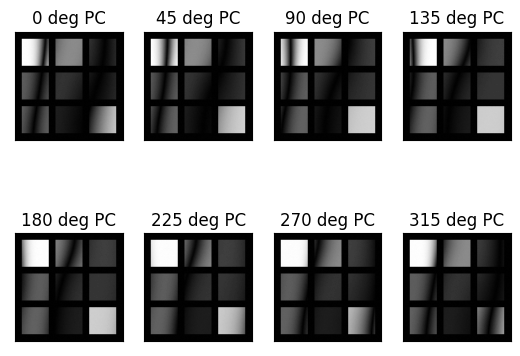

In [3]:
slices = 200
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=8, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    useRotate=True, 
    useDeform=True
)
mssfp.plot_dataset(dataset['M'], slice=0)


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/block_phantom_T2maps_syntheticbanding
Dataset path: D:/DeepSSFP/block_phantom_T2maps_dataset.npy
Creating ds ...
Data shape: (200, 128, 128, 8)
Formatting data...
Dataset: mode:SyntheticBanding, size:200 height:128 width:128 cin:8 cout:8 ratio:0.8
dtype: float64, float64
Using same scaler for SyntheticBanding mode
Training data shape: (160, 128, 128, 8), (160, 128, 128, 8)
Input scaler stats: mean=-0.0039, std=0.0676
Output scaler stats: mean=-0.0039, std=0.0676
Selected indices: [13  9  2]
Figure size: (16, 6)


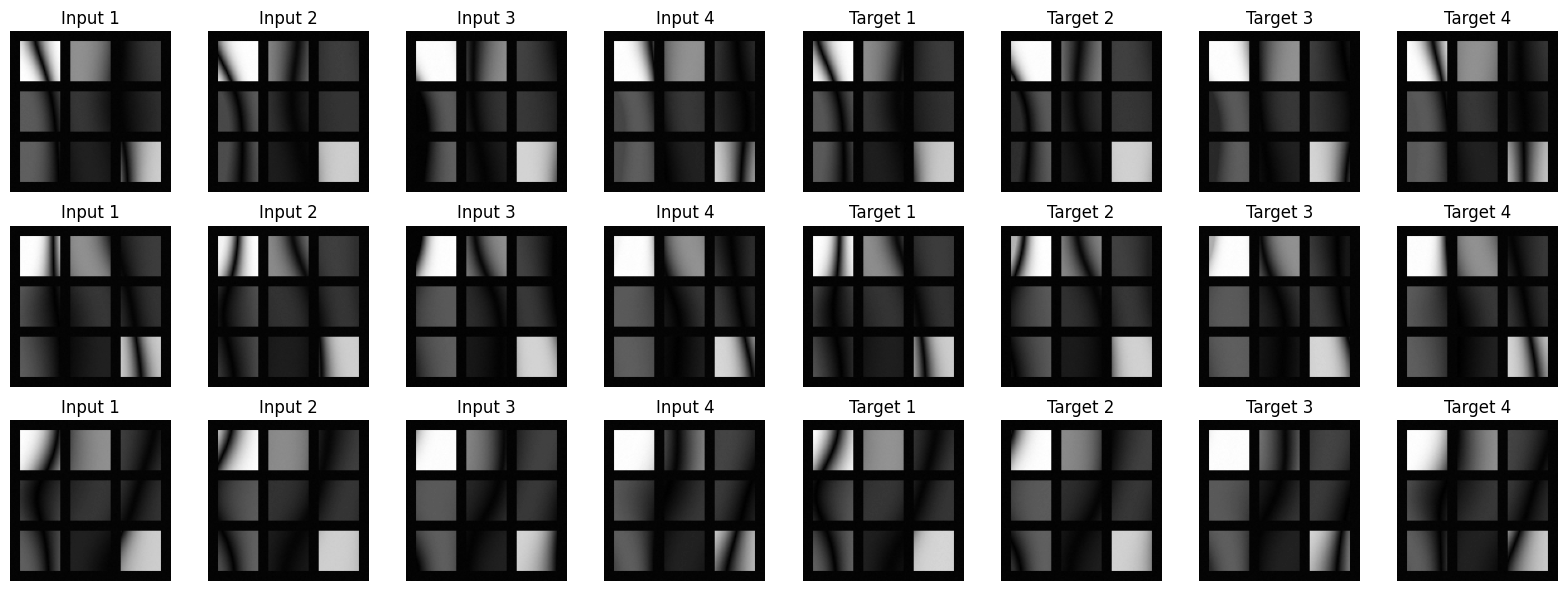

2025-04-22 13:55:22,941 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_T2maps_syntheticbanding



Loading pre-trained model...


2025-04-22 13:55:24,830 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_T2maps_syntheticbanding.keras
2025-04-22 13:55:24,832 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_history.npz
2025-04-22 13:55:26,070 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_training_history.png


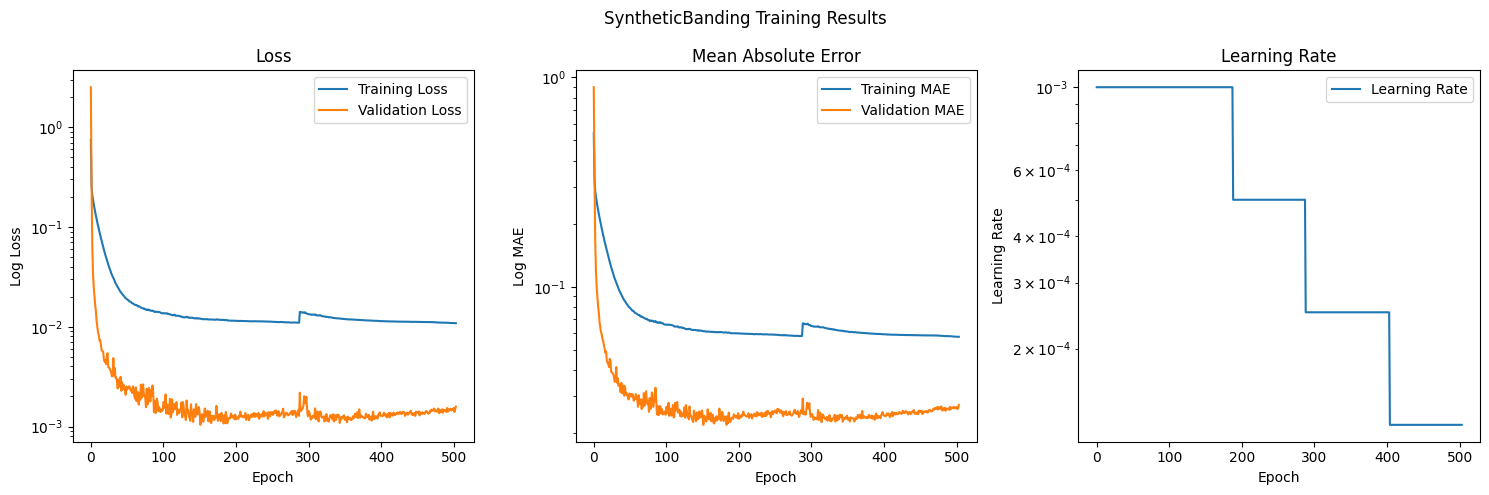

2025-04-22 13:55:26,487 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 8)
2025-04-22 13:55:29,651 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 8)


Selected indices: [27 31]
Figure size: (24, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_prediction_results.png


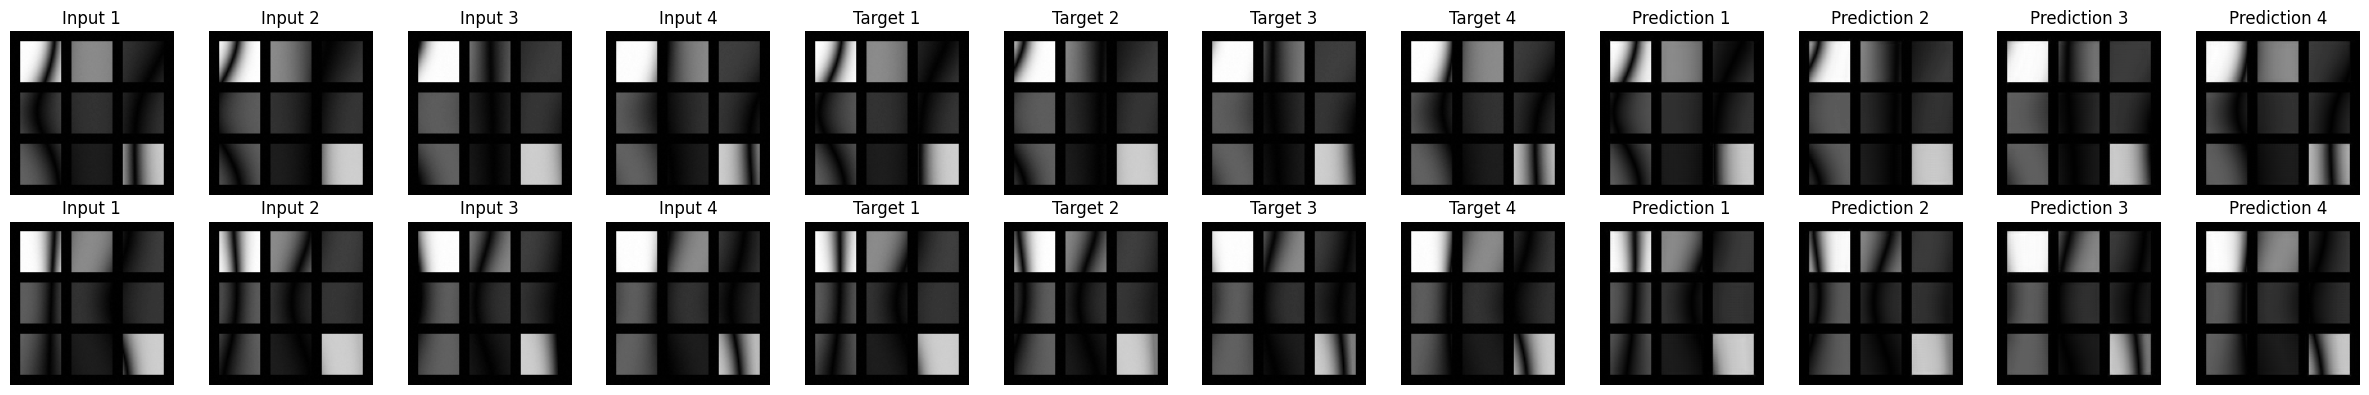

real/imag pairs -> complex
real/imag pairs -> complex
Target shape: (40, 128, 128), Prediction shape: (40, 128, 128)


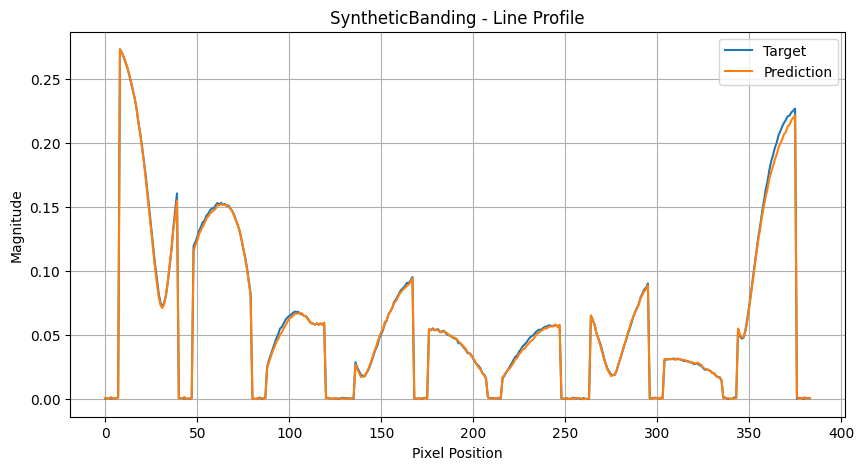


Evaluating band reduction...
Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_band_metrics_scatter


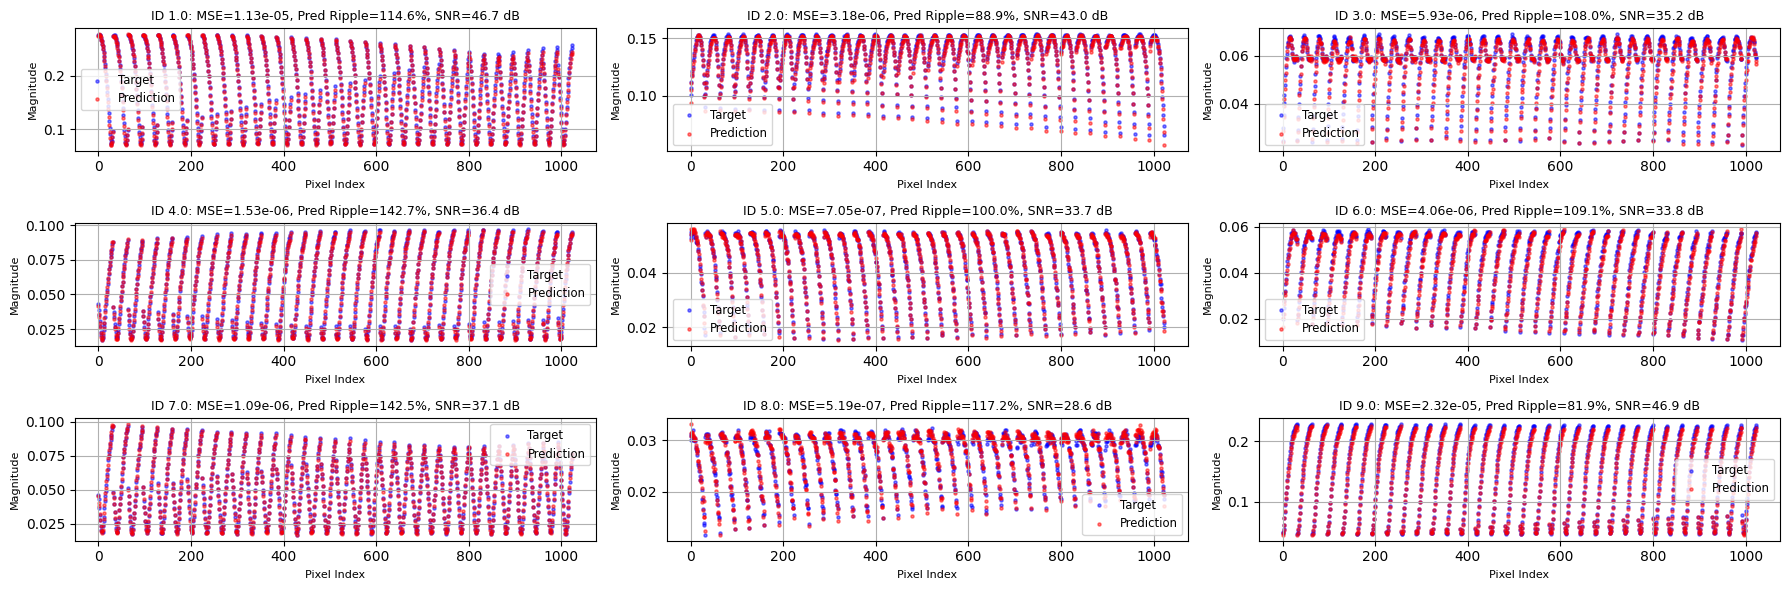

Training history plot saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_band_metrics


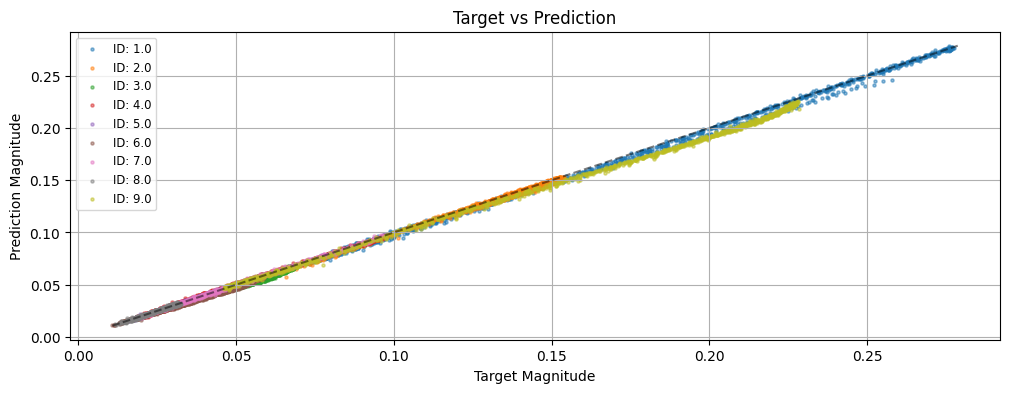


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=1.13e-05, MAE=2.72e-03, Pred Min=0.0716, Pred Max=0.2781, Pred Ripple=114.62%, Pred SNR=46.7 dB, Target Min=0.0732, Target Max=0.2800, Target Ripple=113.31%, Target SNR=48.5 dB, Samples=40, Pixels=1024
ID 2.0: MSE=3.18e-06, MAE=1.22e-03, Pred Min=0.0504, Pred Max=0.1539, Pred Ripple=88.86%, Pred SNR=43.0 dB, Target Min=0.0547, Target Max=0.1537, Target Ripple=84.61%, Target SNR=44.8 dB, Samples=40, Pixels=1024
ID 3.0: MSE=5.93e-06, MAE=1.96e-03, Pred Min=0.0185, Pred Max=0.0680, Pred Ripple=107.98%, Pred SNR=35.2 dB, Target Min=0.0188, Target Max=0.0685, Target Ripple=104.78%, Target SNR=37.2 dB, Samples=40, Pixels=1024
ID 4.0: MSE=1.53e-06, MAE=1.02e-03, Pred Min=0.0167, Pred Max=0.0924, Pred Ripple=142.69%, Pred SNR=36.4 dB, Target Min=0.0171, Target Max=0.0927, Target Ripple=142.11%, Target SNR=38.2 dB, Samples=40, Pixels=1024
ID 5.0: MSE=7.05e-07, MAE=6.13e-04, Pred Min=0.0177, Pred Max=0.0554, Pred Ripple=99.98%, Pr

In [4]:
import deepssfp.analysis
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=False,
    custom_dataset=dataset
)